In [ ]:
!pip install xgboost scikit-learn pandas joblib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

# Update the path based on where your dataset is
df = pd.read_csv('/content/drive/MyDrive/HateSpeechDataset.csv')
df.head()


,Content,Label,Content_int
0,denial of normal the con be asked to comment o...,1,"[146715, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,..."
1,just by being able to tweet this insufferable ...,1,"[146715, 14, 15, 16, 17, 7, 18, 19, 20, 21, 22..."
2,that is retarded you too cute to be single tha...,1,"[146715, 28, 29, 30, 26, 31, 32, 7, 5, 33, 28,..."
3,thought of a real badass mongol style declarat...,1,"[146715, 35, 1, 24, 36, 37, 38, 39, 40, 1, 41,..."
4,afro american basho,1,"[146715, 46, 47, 48, 146714]"


In [ ]:
# Convert text to lowercase and remove special characters
df['Content'] = df['Content'].astype(str).str.lower()
df['Content'] = df['Content'].str.replace(r'[^a-zA-Z\s]', '', regex=True)

df[['Content', 'Label']].head()  # View cleaned text


,Content,Label
0,denial of normal the con be asked to comment o...,1
1,just by being able to tweet this insufferable ...,1
2,that is retarded you too cute to be single tha...,1
3,thought of a real badass mongol style declarat...,1
4,afro american basho,1


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=302)  # Match your original feature count
X = vectorizer.fit_transform(df['Content'])     # Input features
y = df['Label']                                 # Target labels


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Remove any rows where 'Label' is the string 'Label' (header re-imported as row)
df = df[df['Label'] != 'Label']

# Convert labels to integers
df['Label'] = df['Label'].astype(int)

# Reassign X and y
X = vectorizer.fit_transform(df['Content'])
y = df['Label']

# Re-split the data again (do this after fixing y)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



<ipython-input-8-e166540d47b3>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Label'] = df['Label'].astype(int)


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:48:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.842957586754366
              precision    recall  f1-score   support

           0       0.86      0.97      0.91     72346
           1       0.67      0.25      0.36     15834

    accuracy                           0.84     88180
   macro avg       0.76      0.61      0.64     88180
weighted avg       0.82      0.84      0.81     88180



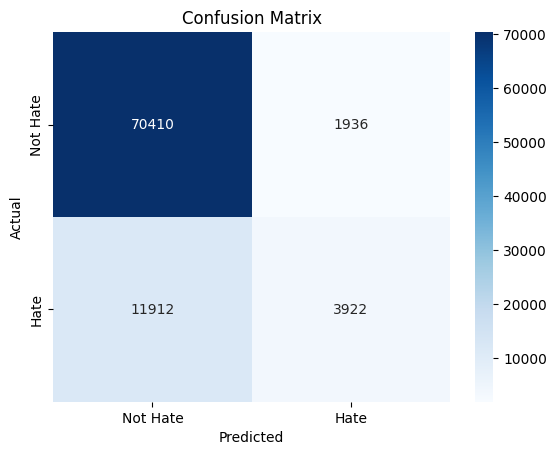

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Hate", "Hate"], yticklabels=["Not Hate", "Hate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


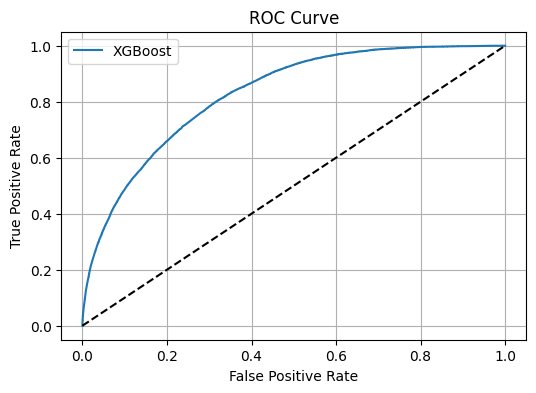

AUC Score: 0.8274474899038657


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='XGBoost')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))


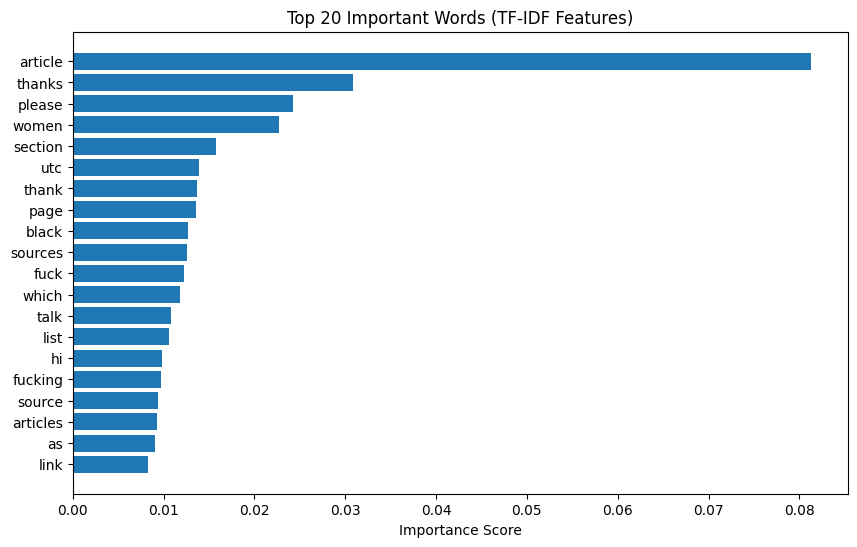

In [ ]:
import numpy as np

# Get feature importances and vocab
importances = xgb_model.feature_importances_
vocab = vectorizer.get_feature_names_out()

# Top 20 important features
top_idx = np.argsort(importances)[-20:]
plt.figure(figsize=(10, 6))
plt.barh(range(20), importances[top_idx])
plt.yticks(range(20), vocab[top_idx])
plt.title("Top 20 Important Words (TF-IDF Features)")
plt.xlabel("Importance Score")
plt.show()


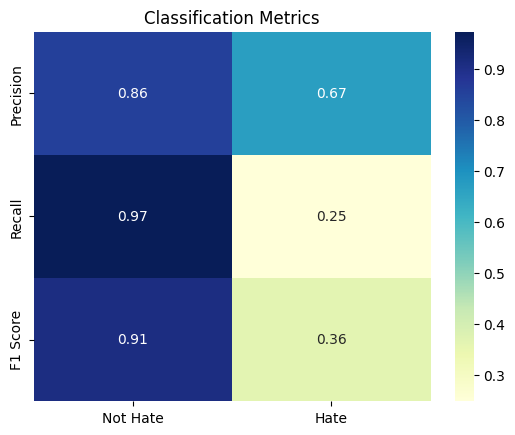

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

report = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
sns.heatmap([report[0], report[1], report[2]], annot=True, fmt=".2f",
            xticklabels=["Not Hate", "Hate"], yticklabels=["Precision", "Recall", "F1 Score"], cmap="YlGnBu")
plt.title("Classification Metrics")
plt.show()


In [ ]:
import joblib

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Save model and vectorizer
joblib.dump(xgb_model, '/content/drive/MyDrive/xgb_model.pkl')
joblib.dump(vectorizer, '/content/drive/MyDrive/tfidf_vectorizer.pkl')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['/content/drive/MyDrive/tfidf_vectorizer.pkl']

In [ ]:
def predict_hate_speech(text):
    # Preprocess input
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Vectorize
    vectorized_text = vectorizer.transform([text])

    # Predict
    prediction = xgb_model.predict(vectorized_text)[0]

    return "Hate Speech 🚫" if prediction == 1 else "Not Hate Speech ✅"


In [ ]:
import re



In [ ]:
predict_hate_speech("I hate you and your kind")


'Hate Speech 🚫'

In [ ]:
predict_hate_speech("you are good boy")

'Not Hate Speech ✅'

In [ ]:
predict_hate_speech("you are rascal")

'Hate Speech 🚫'

In [ ]:
predict_hate_speech("i love you")

'Not Hate Speech ✅'

In [ ]:
predict_hate_speech("you are a dog")


'Hate Speech 🚫'